In [8]:
!pip install --upgrade ipykernel

In [9]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [10]:
# Load the dataset
credit_card_df = pd.read_csv("C:/Users/ABHI ANTONY/Downloads/creditcard.csv/creditcard.csv")
credit_card_df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [12]:
# Display first few rows
print(credit_card_df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [13]:
# Show basic dataset info
print("\nDataset Information:")
print(credit_card_df.info())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

In [6]:
# Check for missing values
print("\nMissing Values in Dataset:")
print(credit_card_df.isnull().sum())



Missing Values in Dataset:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [7]:
# Check class distribution (Fraud vs. Non-Fraud)
print("\nClass Distribution:")
print(credit_card_df["Class"].value_counts())


Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
# Define features (all columns except 'Class') and target variable
X = credit_card_df.drop(columns=["Class"])  # Features (V1-V28, Time, Amount)
y = credit_card_df["Class"]  # Target (Fraud or Non-Fraud)

In [9]:
# Train Random Forest Model to find feature importance
rf_model = RandomForestClassifier(n_estimators=100, random_state=2)
rf_model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [10]:
# Get feature importance scores
feature_importance = rf_model.feature_importances_
feature_importance


array([0.01302535, 0.01316145, 0.01211761, 0.02085564, 0.02643761,
       0.01438267, 0.01275858, 0.02733137, 0.01266726, 0.03012127,
       0.06273621, 0.07023659, 0.13094231, 0.01034288, 0.1333898 ,
       0.01002433, 0.07345419, 0.16326843, 0.03194235, 0.01280237,
       0.0137532 , 0.01610174, 0.0101038 , 0.00738778, 0.00987228,
       0.00870795, 0.01826899, 0.01190684, 0.01044005, 0.01145909])

In [13]:
# Store results in DataFrame
feature_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importance})
feature_df

,Feature,Importance
0,Time,0.013025
1,V1,0.013161
2,V2,0.012118
3,V3,0.020856
4,V4,0.026438
5,V5,0.014383
6,V6,0.012759
7,V7,0.027331
8,V8,0.012667
9,V9,0.030121


In [14]:
# Sort by most important features
feature_df = feature_df.sort_values(by='Importance', ascending=False)
feature_df

,Feature,Importance
17,V17,0.163268
14,V14,0.133390
12,V12,0.130942
16,V16,0.073454
11,V11,0.070237
10,V10,0.062736
18,V18,0.031942
9,V9,0.030121
7,V7,0.027331
4,V4,0.026438


In [15]:
# Display the top important features
print("\nTop Important Features:")
print(feature_df.head(10))


Top Important Features:
   Feature  Importance
17     V17    0.163268
14     V14    0.133390
12     V12    0.130942
16     V16    0.073454
11     V11    0.070237
10     V10    0.062736
18     V18    0.031942
9       V9    0.030121
7       V7    0.027331
4       V4    0.026438


In [16]:
# Split fraud and non-fraud data
fraud_cases = credit_card_df[credit_card_df["Class"] == 1]
non_fraud_cases = credit_card_df[credit_card_df["Class"] == 0]

In [17]:
# Compute mean values for each feature (excluding 'Class')
fraud_mean = fraud_cases.drop(columns=["Class"]).mean()
non_fraud_mean = non_fraud_cases.drop(columns=["Class"]).mean()

In [18]:
# Compare differences
feature_comparison = pd.DataFrame({
    'Feature': fraud_mean.index,  
    'Fraud Mean': fraud_mean.values, 
    'Non-Fraud Mean': non_fraud_mean.values
})

In [19]:
# Calculate the absolute difference
feature_comparison['Difference'] = abs(feature_comparison['Fraud Mean'] - feature_comparison['Non-Fraud Mean'])

In [20]:
# Sort by biggest difference
feature_comparison = feature_comparison.sort_values(by='Difference', ascending=False)
feature_comparison

,Feature,Fraud Mean,Non-Fraud Mean,Difference
0,Time,80746.806911,94838.202258,14091.395347
29,Amount,122.211321,88.291022,33.920299
3,V3,-7.033281,0.012171,7.045452
14,V14,-6.971723,0.012064,6.983787
17,V17,-6.665836,0.011535,6.677371
12,V12,-6.259393,0.010832,6.270225
10,V10,-5.676883,0.009824,5.686707
7,V7,-5.568731,0.009637,5.578368
1,V1,-4.771948,0.008258,4.780206
4,V4,4.542029,-0.007860,4.549889


In [21]:
# Display the most different features
print("\nFeatures with Biggest Difference in Fraud vs. Non-Fraud Transactions:")
print(feature_comparison.head(10))


Features with Biggest Difference in Fraud vs. Non-Fraud Transactions:
   Feature    Fraud Mean  Non-Fraud Mean    Difference
0     Time  80746.806911    94838.202258  14091.395347
29  Amount    122.211321       88.291022     33.920299
3       V3     -7.033281        0.012171      7.045452
14     V14     -6.971723        0.012064      6.983787
17     V17     -6.665836        0.011535      6.677371
12     V12     -6.259393        0.010832      6.270225
10     V10     -5.676883        0.009824      5.686707
7       V7     -5.568731        0.009637      5.578368
1       V1     -4.771948        0.008258      4.780206
4       V4      4.542029       -0.007860      4.549889


In [22]:
# Compute correlation matrix
correlation_matrix = credit_card_df.corr()
correlation_matrix

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447
V5,0.173072,1.812612e-17,5.157519e-16,-6.539009e-17,-1.719944e-15,1.000000e+00,2.408382e-16,2.715541e-16,7.437229e-16,7.391702e-16,...,-3.920976e-16,1.253751e-16,-8.428683e-18,-1.149255e-15,4.808532e-16,4.319541e-16,6.590482e-16,-5.613951e-18,-0.386356,-0.094974
V6,-0.063016,-6.506567e-16,2.787346e-16,1.627627e-15,-7.491959e-16,2.408382e-16,1.000000e+00,1.191668e-16,-1.104219e-16,4.131207e-16,...,5.833316e-17,-4.705235e-19,1.046712e-16,-1.071589e-15,4.562861e-16,-1.357067e-16,-4.452461e-16,2.594754e-16,0.215981,-0.043643
V7,0.084714,-1.005191e-15,2.055934e-16,4.895305e-16,-4.104503e-16,2.715541e-16,1.191668e-16,1.000000e+00,3.344412e-16,1.122501e-15,...,-2.027779e-16,-8.898922e-16,-4.387401e-16,7.434913e-18,-3.094082e-16,-9.657637e-16,-1.782106e-15,-2.776530e-16,0.397311,-0.187257
V8,-0.036949,-2.433822e-16,-5.377041e-17,-1.268779e-15,5.697192e-16,7.437229e-16,-1.104219e-16,3.344412e-16,1.000000e+00,4.356078e-16,...,3.892798e-16,2.026927e-16,6.377260e-17,-1.047097e-16,-4.653279e-16,-1.727276e-16,1.299943e-16,-6.200930e-16,-0.103079,0.019875
V9,-0.008660,-1.513678e-16,1.978488e-17,5.568367e-16,6.923247e-16,7.391702e-16,4.131207e-16,1.122501e-15,4.356078e-16,1.000000e+00,...,1.936953e-16,-7.071869e-16,-5.214137e-16,-1.430343e-16,6.757763e-16,-7.888853e-16,-6.709655e-17,1.110541e-15,-0.044246,-0.097733


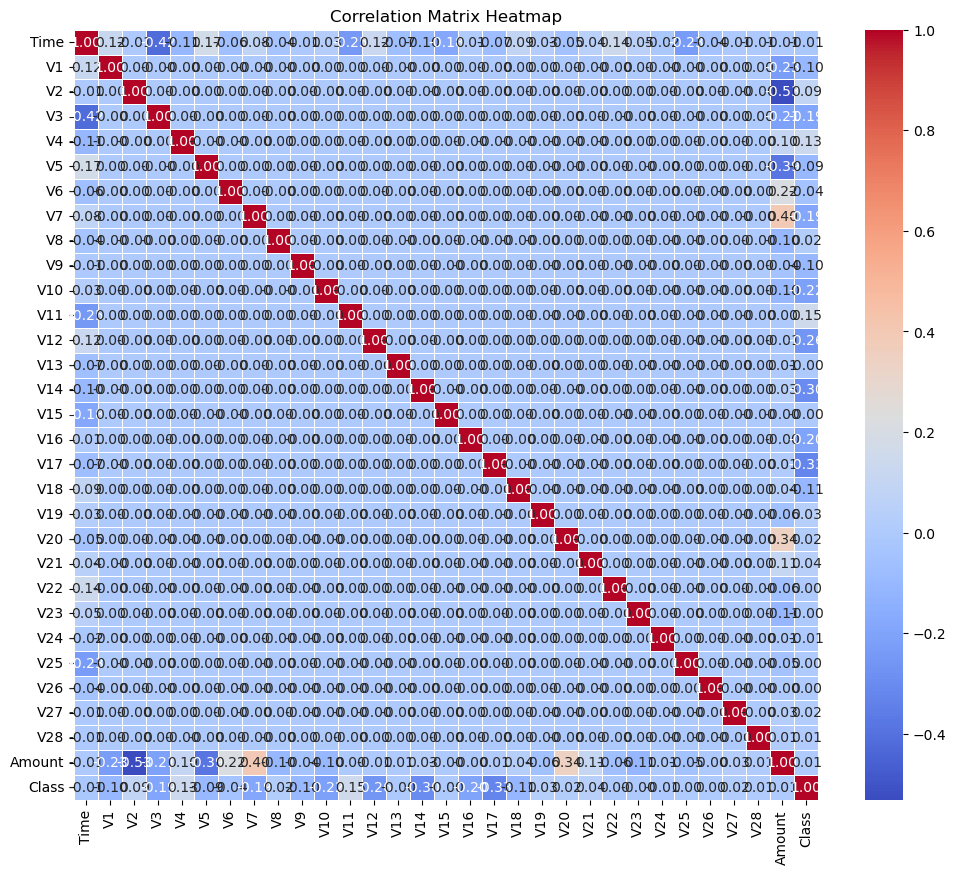

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = credit_card_df.corr()

# Set figure size
plt.figure(figsize=(12, 10))

# Plot heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# Add title
plt.title("Correlation Matrix Heatmap")

# Show plot
plt.show()

In [24]:
# Get correlation of features with the target variable (Class)
correlation_with_fraud = correlation_matrix["Class"].drop("Class")  # Drop self-correlation
correlation_with_fraud

Time     -0.012323
V1       -0.101347
V2        0.091289
V3       -0.192961
V4        0.133447
V5       -0.094974
V6       -0.043643
V7       -0.187257
V8        0.019875
V9       -0.097733
V10      -0.216883
V11       0.154876
V12      -0.260593
V13      -0.004570
V14      -0.302544
V15      -0.004223
V16      -0.196539
V17      -0.326481
V18      -0.111485
V19       0.034783
V20       0.020090
V21       0.040413
V22       0.000805
V23      -0.002685
V24      -0.007221
V25       0.003308
V26       0.004455
V27       0.017580
V28       0.009536
Amount    0.005632
Name: Class, dtype: float64

In [25]:
# Sort by strongest correlation (absolute values)
correlation_with_fraud = correlation_with_fraud.abs().sort_values(ascending=False)
correlation_with_fraud

V17       0.326481
V14       0.302544
V12       0.260593
V10       0.216883
V16       0.196539
V3        0.192961
V7        0.187257
V11       0.154876
V4        0.133447
V18       0.111485
V1        0.101347
V9        0.097733
V5        0.094974
V2        0.091289
V6        0.043643
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
Time      0.012323
V28       0.009536
V24       0.007221
Amount    0.005632
V13       0.004570
V26       0.004455
V15       0.004223
V25       0.003308
V23       0.002685
V22       0.000805
Name: Class, dtype: float64

In [26]:
# Display top correlated features
print("\nTop Features Correlated with Fraud:")
print(correlation_with_fraud.head(10))


Top Features Correlated with Fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


In [27]:
# Select the most correlated features for training
important_features = ["V17", "V14", "V12", "V10"]
X_selected = credit_card_df[important_features]
y = credit_card_df["Class"]

In [28]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=2)

In [29]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=2)
rf_model.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Make predictions
y_pred = rf_model.predict(X_test)

In [31]:
# Evaluate Model Performance
print("✅ Model Accuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")
print("✅ Precision:", round(precision_score(y_test, y_pred), 4))
print("✅ Recall:", round(recall_score(y_test, y_pred), 4))

✅ Model Accuracy: 99.96 %
✅ Precision: 0.9101
✅ Recall: 0.8265


In [32]:
# Fine-tune Random Forest model
rf_model_tuned = RandomForestClassifier(
    n_estimators=200,   # Increase number of trees
    max_depth=15,       # Control depth to prevent overfitting
    min_samples_split=5,  # Require at least 5 samples to split
    random_state=2,
    n_jobs=-1
)

In [33]:
# Train tuned model
rf_model_tuned.fit(X_train, y_train)

# Make predictions
y_pred_tuned = rf_model_tuned.predict(X_test)

In [34]:
# Evaluate performance
print("✅ Tuned Model Precision:", round(precision_score(y_test, y_pred_tuned), 4))
print("✅ Tuned Model Recall:", round(recall_score(y_test, y_pred_tuned), 4))

✅ Tuned Model Precision: 0.9101
✅ Tuned Model Recall: 0.8265


C:\Users\ABHI ANTONY\AppData\Local\Temp\ipykernel_22768\3545389503.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_df['Importance'], y=feature_df['Feature'], palette='viridis')


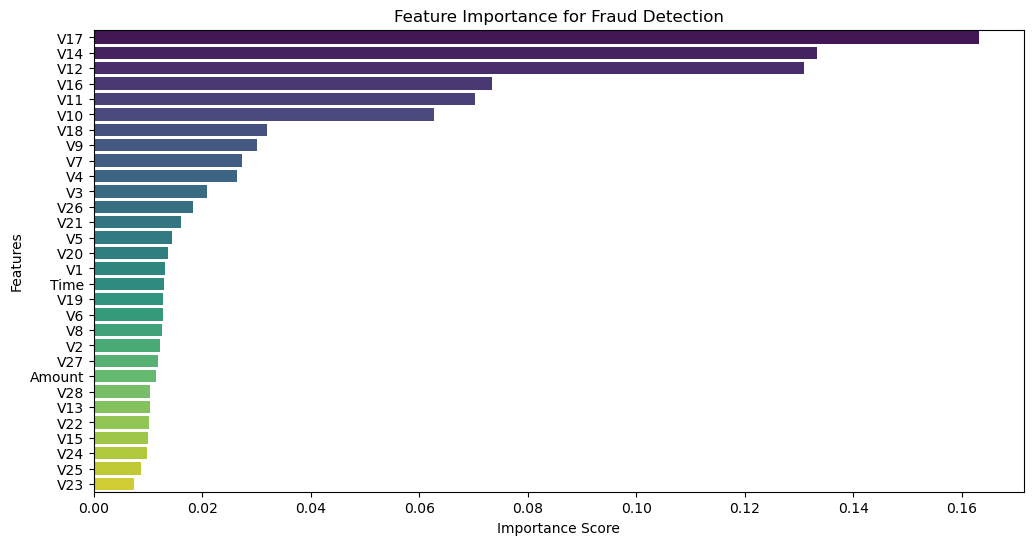

In [35]:
# Plot feature importance
plt.figure(figsize=(12,6))
sns.barplot(x=feature_df['Importance'], y=feature_df['Feature'], palette='viridis')
plt.title("Feature Importance for Fraud Detection")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [36]:
# Select only the top important features
top_features = ["V17", "V14", "V12", "V16", "V11", "V10"]
X_selected = credit_card_df[top_features]
y = credit_card_df["Class"]

In [37]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, stratify=y, random_state=2)

In [38]:
# Train Random Forest Model
rf_final = RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=2)
rf_final.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [39]:
# Make predictions
y_pred_final = rf_final.predict(X_test)

In [40]:
# Evaluate model performance
print("✅ Final Model Accuracy:", round(accuracy_score(y_test, y_pred_final) * 100, 2), "%")
print("✅ Final Model Precision:", round(precision_score(y_test, y_pred_final), 4))
print("✅ Final Model Recall:", round(recall_score(y_test, y_pred_final), 4))

✅ Final Model Accuracy: 99.95 %
✅ Final Model Precision: 0.8817
✅ Final Model Recall: 0.8367


In [41]:
import joblib

In [42]:
# Save the trained model
joblib.dump(rf_final, "fraud_detection_rf.pkl")

['fraud_detection_rf.pkl']